In [68]:
import warnings  
warnings.filterwarnings("ignore")
import pandas as pd                           # For data handling
from sklearn.model_selection import train_test_split  # For splitting data into training and testing
from xgboost import XGBRegressor  # Import XGBoost model and evaluation tools
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # For evaluating model
import matplotlib.pyplot as plt   # For plotting
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from math import sqrt

In [69]:
# Load the dataset
data = pd.read_csv("train.csv")

In [70]:
data

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,1199995,36.0,Female,27316.0,Married,0.0,Master's,Unemployed,13.772907,Urban,...,NaN,5.0,372.0,3.0,2023-05-03 15:21:39.257696,Poor,No,Daily,Apartment,1303.0
1199996,1199996,54.0,Male,35786.0,Divorced,NaN,Master's,Self-Employed,11.483482,Rural,...,NaN,10.0,597.0,4.0,2022-09-10 15:21:39.134960,Poor,No,Weekly,Apartment,821.0
1199997,1199997,19.0,Male,51884.0,Divorced,0.0,Master's,NaN,14.724469,Suburban,...,0.0,19.0,NaN,6.0,2021-05-25 15:21:39.106582,Good,No,Monthly,Condo,371.0
1199998,1199998,55.0,Male,NaN,Single,1.0,PhD,NaN,18.547381,Suburban,...,1.0,7.0,407.0,4.0,2021-09-19 15:21:39.190215,Poor,No,Daily,Apartment,596.0


In [71]:
data.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [72]:
data.describe()

,id,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1.200000e+06,1.181295e+06,1.155051e+06,1.090328e+06,1.125924e+06,835971.000000,1.199994e+06,1.062118e+06,1.199999e+06,1.200000e+06
mean,5.999995e+05,4.114556e+01,3.274522e+04,2.009934e+00,2.561391e+01,1.002689,9.569889e+00,5.929244e+02,5.018219e+00,1.102545e+03
std,3.464103e+05,1.353995e+01,3.217951e+04,1.417338e+00,1.220346e+01,0.982840,5.776189e+00,1.499819e+02,2.594331e+00,8.649989e+02
min,0.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,2.012237e+00,0.000000,0.000000e+00,3.000000e+02,1.000000e+00,2.000000e+01
25%,2.999998e+05,3.000000e+01,8.001000e+03,1.000000e+00,1.591896e+01,0.000000,5.000000e+00,4.680000e+02,3.000000e+00,5.140000e+02
50%,5.999995e+05,4.100000e+01,2.391100e+04,2.000000e+00,2.457865e+01,1.000000,1.000000e+01,5.950000e+02,5.000000e+00,8.720000e+02
75%,8.999992e+05,5.300000e+01,4.463400e+04,3.000000e+00,3.452721e+01,2.000000,1.500000e+01,7.210000e+02,7.000000e+00,1.509000e+03
max,1.199999e+06,6.400000e+01,1.499970e+05,4.000000e+00,5.897591e+01,9.000000,1.900000e+01,8.490000e+02,9.000000e+00,4.999000e+03


In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

In [74]:
data.isnull().sum()

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [75]:
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Annual Income'].fillna(data['Annual Income'].median(), inplace=True)
data['Marital Status'].fillna(data['Marital Status'].mode()[0], inplace=True)
data['Number of Dependents'].fillna(data['Number of Dependents'].mode()[0], inplace=True)
data['Health Score'].fillna(data['Health Score'].mean(), inplace=True)
data['Previous Claims'].fillna(0, inplace=True)
data['Vehicle Age'].fillna(data['Vehicle Age'].mode()[0], inplace=True)
data['Credit Score'].fillna(data['Credit Score'].mean(), inplace=True)
data['Insurance Duration'].fillna(data['Insurance Duration'].mean(), inplace=True)
# Handle 'Customer Feedback' based on its type
if data['Customer Feedback'].dtype == 'object':
    data['Occupation'].fillna(data['Occupation'].mode()[0], inplace=True)
else:
    data['Customer Feedback'].fillna(data['Customer Feedback'].mean(), inplace=True)

In [76]:
data.isnull().sum()

id                          0
Age                         0
Gender                      0
Annual Income               0
Marital Status              0
Number of Dependents        0
Education Level             0
Occupation                  0
Health Score                0
Location                    0
Policy Type                 0
Previous Claims             0
Vehicle Age                 0
Credit Score                0
Insurance Duration          0
Policy Start Date           0
Customer Feedback       77824
Smoking Status              0
Exercise Frequency          0
Property Type               0
Premium Amount              0
dtype: int64

In [77]:
# Drop unnecessary columns
data = data.drop(columns=["id","Customer Feedback"])

In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 19 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1200000 non-null  float64
 1   Gender                1200000 non-null  object 
 2   Annual Income         1200000 non-null  float64
 3   Marital Status        1200000 non-null  object 
 4   Number of Dependents  1200000 non-null  float64
 5   Education Level       1200000 non-null  object 
 6   Occupation            1200000 non-null  object 
 7   Health Score          1200000 non-null  float64
 8   Location              1200000 non-null  object 
 9   Policy Type           1200000 non-null  object 
 10  Previous Claims       1200000 non-null  float64
 11  Vehicle Age           1200000 non-null  float64
 12  Credit Score          1200000 non-null  float64
 13  Insurance Duration    1200000 non-null  float64
 14  Policy Start Date     1200000 non-

In [79]:
from sklearn.preprocessing import LabelEncoder

data['Gender'] = LabelEncoder().fit_transform(data['Gender'])
data['Marital Status'] = LabelEncoder().fit_transform(data['Marital Status'])
data['Education Level'] = LabelEncoder().fit_transform(data['Education Level'])
data['Occupation'] = LabelEncoder().fit_transform(data['Occupation'])
data['Location'] = LabelEncoder().fit_transform(data['Location'])
data['Policy Type'] = LabelEncoder().fit_transform(data['Policy Type'])
data['Smoking Status'] = LabelEncoder().fit_transform(data['Smoking Status'])
data['Exercise Frequency'] = LabelEncoder().fit_transform(data['Exercise Frequency'])
data['Property Type'] = LabelEncoder().fit_transform(data['Property Type'])
data['Policy Start Date'] = LabelEncoder().fit_transform(data['Policy Start Date'])


In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 19 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1200000 non-null  float64
 1   Gender                1200000 non-null  int64  
 2   Annual Income         1200000 non-null  float64
 3   Marital Status        1200000 non-null  int64  
 4   Number of Dependents  1200000 non-null  float64
 5   Education Level       1200000 non-null  int64  
 6   Occupation            1200000 non-null  int64  
 7   Health Score          1200000 non-null  float64
 8   Location              1200000 non-null  int64  
 9   Policy Type           1200000 non-null  int64  
 10  Previous Claims       1200000 non-null  float64
 11  Vehicle Age           1200000 non-null  float64
 12  Credit Score          1200000 non-null  float64
 13  Insurance Duration    1200000 non-null  float64
 14  Policy Start Date     1200000 non-

# Pre Processing

In [1]:
# Separate features (X) and target (y)
x = df.drop("Premium Amount", axis=1)  # All columns except target
y = df["Premium Amount"]  # Target variable

NameError: name 'data' is not defined

In [82]:
# Split data into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [83]:
# Apply Standard Scaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)  # Fit and transform on training data
x_test_scaled = scaler.transform(x_test)    

# Create Model

In [96]:
# Create the XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

In [97]:
#Train the model
xgb_model.fit(x_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [98]:
# Predict on test data
y_pred_xgb = xgb_model.predict(x_test_scaled)

In [99]:
y_pred_xgb

array([1174.5532, 1252.7517, 1129.6514, ..., 1085.7075, 1406.3875,
       1044.2776], dtype=float32)

In [100]:
# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = sqrt(mean_squared_error(y_test, y_pred_xgb)) # Root Mean Squared Error
r2_xgb = r2_score(y_test, y_pred_xgb)

In [101]:
# Print results
print("XGBoost Regressor Performance:")
print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R² Score: {r2_xgb:.4f}")

XGBoost Regressor Performance:
MAE: 643.59
RMSE: 844.49
R² Score: 0.0457


In [102]:
print("Training accuracy: ", xgb_model.score(x_test_scaled, y_test))

Training accuracy:  0.04566937257221482


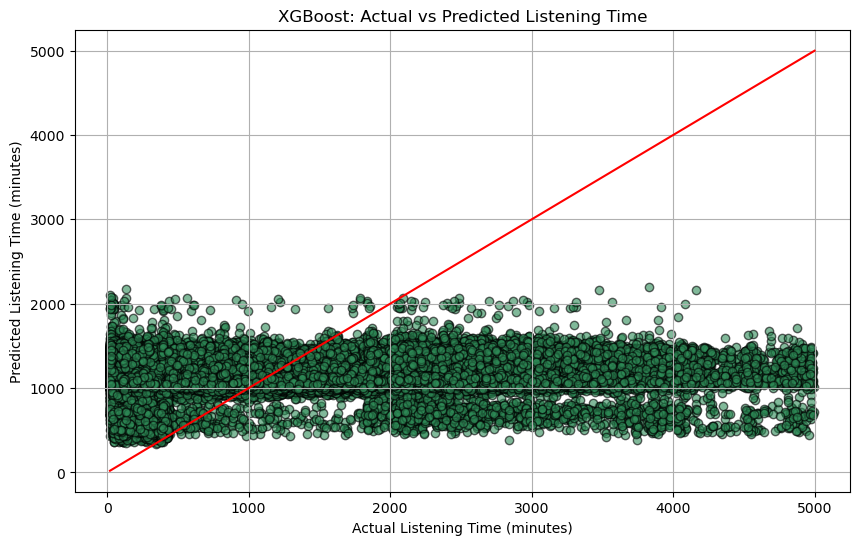

In [104]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, color='seagreen', alpha=0.6, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel("Actual Listening Time (minutes)")
plt.ylabel("Predicted Listening Time (minutes)")
plt.title("XGBoost: Actual vs Predicted Listening Time")
plt.grid(True)
plt.show()

In [ ]:
import pickle

# Suppose your trained model is rf_model
with open("xgb_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)
